# One-Phonon Diffuse Scattering — Rigid-Body Crystal (6o2h, P1)

One rigid body per unit cell (the lysozyme molecule), 6 degrees of freedom
per cell: a rotation $\Omega$ and a translation $v$. The crystal's phonons
are the normal modes of a Born–von Kármán lattice of these rigid bodies,
coupled through a small set of pairwise contact springs. The notebook builds
the model from the deposited structure, fits contact stiffnesses to
diffuse-scattering data, and visualizes the resulting phonon modes.

**Pipeline:** hybrid electron density → coupling vector $G(\mathbf q)$ →
contact detection and framing → dynamical matrix → band structure and
diffuse-scattering maps → synthetic-data refinement → predicted atomic
displacement parameters → mode animations.


In [1]:
import io
import pathlib
from itertools import product

import numpy as np
import gemmi
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.lines import Line2D
import scipy.constants as const
from scipy.spatial import cKDTree
from scipy.linalg import eigh
from scipy.ndimage import zoom as nd_zoom
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components as sc_connected_components
from scipy.interpolate import griddata
from scipy.optimize import minimize
from scipy.spatial.transform import Rotation as Rot
import imageio
import imageio.v2 as iio2
from skimage.measure import marching_cubes
from IPython.display import Image as IPImage, display
import gc

np.set_printoptions(precision=4, suppress=True)

def fig_to_image(fig, dpi=72):
    """Rasterize a matplotlib figure to an RGB array, for building GIFs."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=dpi, bbox_inches='tight', facecolor=fig.get_facecolor())
    buf.seek(0)
    return iio2.imread(buf)[:, :, :3]


In [2]:
PDB_FILE = pathlib.Path("6o2h.cif")
SF_CIF   = pathlib.Path("6o2h-sf.cif")

D_MIN_MODEL    = 1.5    # Å — resolution for model density (phases)
RATE_MODEL     = 1.5
CONTACT_CUTOFF = 4.0    # Å — atom-atom cutoff defining a rigid-body contact
MIN_CONTACTS   = 5      # minimum atom-atom pairs for a contact to count
MAX_IMAGE      = 1      # search ±MAX_IMAGE unit cells in each direction
D_MIN_DIFFUSE  = 3.0    # Å — resolution cutoff for the diffuse map
NPLOT_HK       = 8      # sub-integer grid density per Miller index;
                        # D_MIN_DIFFUSE sets how many Bragg peaks appear
                        # (h_max ∝ 1/D_MIN_DIFFUSE); NPLOT_HK sets the
                        # inter-Bragg sampling density independently.
TEMPERATURE    = 300.0  # K — used only for the frequency-unit conversion

LAMBDA_REG     = 0.05   # regularization weight on local-frame T–R coupling


In [3]:
st = gemmi.read_structure(str(PDB_FILE))
st.remove_hydrogens()
st.remove_waters()
st.setup_entities()

cell = st.cell
a1 = np.array(cell.orthogonalize(gemmi.Fractional(1,0,0)).tolist())
a2 = np.array(cell.orthogonalize(gemmi.Fractional(0,1,0)).tolist())
a3 = np.array(cell.orthogonalize(gemmi.Fractional(0,0,1)).tolist())
A_orth  = np.column_stack([a1, a2, a3])       # orthogonalization matrix
B_recip = 2*np.pi * np.linalg.inv(A_orth).T   # reciprocal lattice (columns)

print(f"Cell: {cell.a:.3f}×{cell.b:.3f}×{cell.c:.3f} Å  "
      f"α={cell.alpha:.2f} β={cell.beta:.2f} γ={cell.gamma:.2f}°")
print(f"Space group: {st.spacegroup_hm}   Volume: {cell.volume:.1f} Å³")


Cell: 27.424×32.134×34.513 Å  α=88.66 β=108.46 γ=111.88°
Space group: P 1   Volume: 26616.9 Å³


## Electron Density

The model density from the deposited coordinates supplies phases; the
measured structure-factor amplitudes replace the model amplitudes wherever
a measurement exists. This hybrid density is the one used everywhere below
to compute the coupling vector $G(\mathbf q)$ and the molecular isosurface.


In [4]:
dc = gemmi.DensityCalculatorX()
dc.d_min = D_MIN_MODEL; dc.rate = RATE_MODEL
dc.set_grid_cell_and_spacegroup(st)
dc.initialize_grid()
dc.add_model_density_to_grid(st[0])
dc.grid.symmetrize_sum()

rho_model   = np.array(dc.grid)
nu_m, nv_m, nw_m = rho_model.shape
F_calc_grid = np.fft.ifftn(rho_model)   # F_calc(h,k,l)/V at [h%nu,k%nv,l%nw]

doc_sf = gemmi.cif.read(str(SF_CIF))
rb     = gemmi.as_refln_blocks(doc_sf)[0]
miller = np.array(rb.make_miller_array())
F_meas = np.array(rb.make_float_array("F_meas_au"))
valid  = np.isfinite(F_meas) & (F_meas > 0)
miller, F_meas = miller[valid], F_meas[valid]

h_i = miller[:,0] % nu_m; k_i = miller[:,1] % nv_m; l_i = miller[:,2] % nw_m
phase_calc = np.angle(F_calc_grid[h_i, k_i, l_i])
F_hybrid   = F_meas * np.exp(1j * phase_calc)

F_grid = np.zeros((nu_m, nv_m, nw_m), dtype=complex)
F_grid[h_i, k_i, l_i] = F_hybrid / cell.volume
F_grid[(-miller[:,0])%nu_m, (-miller[:,1])%nv_m, (-miller[:,2])%nw_m] = \
    F_hybrid.conj() / cell.volume

rho = np.fft.fftn(F_grid).real.astype(np.float32)
nu, nv, nw = rho.shape
dV = cell.volume / rho.size
print(f"Grid: {nu}×{nv}×{nw}   dV={dV:.4f} Å³   reflections: {valid.sum()}")


Grid: 60×72×72   dV=0.0856 Å³   reflections: 30103


In [5]:
# The model density (protein atoms only) has no missing low-resolution terms
# and integrates to the correct electron count, so it is used directly as the
# protein/solvent mask rather than a separate solvent-flattening step.
rho_model_norm = rho_model / rho_model.max()
mask_model = (rho_model_norm > 0.02)   # ~2% of peak: catches all atom-adjacent voxels

if rho.shape != mask_model.shape:
    mask = nd_zoom(mask_model.astype(float),
                   np.array(rho.shape)/np.array(mask_model.shape), order=1) > 0.5
else:
    mask = mask_model

rho_masked = rho * mask
dV_model = cell.volume / rho_model.size
Z_model  = rho_model.sum() * dV_model
print(f"Mask: {mask.mean():.1%} of voxels are protein")
print(f"Model electron content: {Z_model:.1f} e⁻")
print(f"Hybrid density integral over protein region: {rho_masked.sum()*dV:.1f} e⁻")


Mask: 19.4% of voxels are protein
Model electron content: 6879.3 e⁻
Hybrid density integral over protein region: 3582.1 e⁻


In [6]:
ii = np.arange(nu)/nu; jj = np.arange(nv)/nv; kk = np.arange(nw)/nw
Ig, Jg, Kg = np.meshgrid(ii, jj, kk, indexing='ij')
r_xyz = (A_orth @ np.stack([Ig,Jg,Kg]).reshape(3,-1)).reshape(3,nu,nv,nw)

w = rho_masked.ravel()
r_cm = (r_xyz.reshape(3,-1) * w).sum(1) / w.sum()
print(f"Density CM: ({r_cm[0]:.2f}, {r_cm[1]:.2f}, {r_cm[2]:.2f}) Å")


Density CM: (1.39, 13.13, 17.36) Å


## Coupling Vector $G(\mathbf{q})$

$$G = \begin{pmatrix}G_R\\G_T\end{pmatrix}
    = \begin{pmatrix}i\mathbf{q}\times L(\mathbf{q})\\
                      i\mathbf{q}\,F(\mathbf{q})\end{pmatrix},
\quad F = \int\rho\,e^{-i\mathbf{q}\cdot\mathbf{r}}d^3r,
\quad L = \int(\mathbf{r}-\mathbf{r}_{\rm cm})\rho\,e^{-i\mathbf{q}\cdot\mathbf{r}}d^3r$$

We zero-pad the density before the FFT to sample $F$ and $L$ on a finer
reciprocal grid, by a factor $P$ = `NPLOT_HK`:
$\mathbf q = (h/P)\mathbf b_1 + (k/P)\mathbf b_2 + (l/P)\mathbf b_3$ for
integer $h,k,l$.


In [7]:
P    = NPLOT_HK
nu_f = nu * P
nv_f = nv * P
nw_f = nw * P

rho_w = rho_model * dV_model                # ρ × volume element: F(000) = Z_model
dr    = r_xyz - r_cm[:, None, None, None]    # r − r_cm on the model grid

rho_w_pad = np.zeros((nu_f, nv_f, nw_f), dtype=np.float64)
rho_w_pad[:nu, :nv, :nw] = rho_w
F_fine = np.fft.ifftn(rho_w_pad) * rho_w_pad.size

L_fine = np.zeros((3, nu_f, nv_f, nw_f), dtype=complex)
for _ax in range(3):
    _pad = np.zeros((nu_f, nv_f, nw_f), dtype=np.float64)
    _pad[:nu, :nv, :nw] = dr[_ax] * rho_w
    L_fine[_ax] = np.fft.ifftn(_pad) * _pad.size

F000 = float(F_fine[0, 0, 0].real)
print(f"F(000) = {F000:.1f} e⁻  (compare Z_model = {Z_model:.1f})")
print(f"Fine grid: {nu_f}×{nv_f}×{nw_f}   oversampling P={P}   "
      f"Δh=Δk=Δl=1/{P}={1/P:.4f}")

def G_at_hkl(h, k, l):
    """G(q) at fractional Miller indices (h, k, l), read exactly off the
    padded FFT when h,k,l are multiples of 1/P; otherwise rounded to the
    nearest such point (error at most 0.5/P Miller-index units)."""
    q  = h*B_recip[:, 0] + k*B_recip[:, 1] + l*B_recip[:, 2]
    iq = 1j * q
    hi = round(float(h) * P) % nu_f
    ki = round(float(k) * P) % nv_f
    li = round(float(l) * P) % nw_f
    F  = F_fine[hi, ki, li]
    L  = L_fine[:, hi, ki, li]
    return np.concatenate([np.cross(iq, L), iq * F])


F(000) = 6879.3 e⁻  (compare Z_model = 6879.3)
Fine grid: 480×576×576   oversampling P=8   Δh=Δk=Δl=1/8=0.1250


## Rigid-Body Contacts

Two unit-cell images are considered in contact if any of their atoms come
within `CONTACT_CUTOFF`. Born–von Kármán translational symmetry means the
contact between cell 0 and cell $\mathbf n$ depends only on $\mathbf n$, and
the two directions of a contact ($\mathbf n$ and $-\mathbf n$) are the same
physical spring seen from either side. For 6o2h this leaves 6 symmetry-
distinct contacts, each carrying an independent $6\times 6$ stiffness matrix.

For each contact we also record the centroid of the atom pairs that are
actually within the cutoff — the physical location of the contact patch —
which is used below to define a contact-local reference frame for $K$.


In [8]:
all_pos = np.array([atom.pos.tolist() for ch in st[0] for res in ch for atom in res])
tree    = cKDTree(all_pos)

def canonical(n):
    return min(n, tuple(-x for x in n))

raw_interfaces = {}
for n_tup in product(range(-MAX_IMAGE, MAX_IMAGE+1), repeat=3):
    if n_tup == (0,0,0):
        continue
    R_n = sum(n_tup[i]*[a1,a2,a3][i] for i in range(3))
    idx_lists = tree.query_ball_point(all_pos + R_n, CONTACT_CUTOFF)
    n_c = sum(len(idx) for idx in idx_lists)
    if n_c >= MIN_CONTACTS:
        raw_interfaces[n_tup] = {'R_n': R_n, 'n_contacts': n_c, 'idx_lists': idx_lists}

unique = {}
for n_tup, info in raw_interfaces.items():
    c = canonical(n_tup)
    if c not in unique:
        unique[c] = dict(info, n_tup=n_tup)

def contact_centroid(R_n, idx_lists):
    """Centroid (lab frame) of the midpoints of all atom pairs within
    CONTACT_CUTOFF for the image shifted by R_n."""
    mids = []
    for j, idx_i in enumerate(idx_lists):
        for i in idx_i:
            mids.append(0.5*(all_pos[i] + all_pos[j] + R_n))
    return np.mean(mids, axis=0)

for c, info in unique.items():
    info['contact_pt'] = contact_centroid(info['R_n'], info['idx_lists'])

shell_order = sorted(unique.keys())
print(f"Detected {len(unique)} symmetry-distinct contacts "
      f"({len(raw_interfaces)} directed images):")
for c in shell_order:
    info = unique[c]
    print(f"  n={c}  |R_n|={np.linalg.norm(info['R_n']):.2f} Å  "
          f"atom-pairs={info['n_contacts']}")


Detected 6 symmetry-distinct contacts (12 directed images):
  n=(-1, -1, 0)  |R_n|=33.58 Å  atom-pairs=33
  n=(-1, 0, -1)  |R_n|=36.66 Å  atom-pairs=16
  n=(-1, 0, 0)  |R_n|=27.42 Å  atom-pairs=31
  n=(0, -1, 0)  |R_n|=32.13 Å  atom-pairs=63
  n=(0, -1, 1)  |R_n|=46.60 Å  atom-pairs=9
  n=(0, 0, -1)  |R_n|=34.51 Å  atom-pairs=53


## Mass Matrix

$M = \mathrm{diag}(J, mI)$, with $J$ the moment-of-inertia tensor about the
atomic center of mass and $m$ the total mass. Frequencies are reported in a
reduced unit system in which stiffnesses are expressed directly in units of
$k_BT$ (so $k_BT=1$ throughout — no separate Boltzmann factor appears in the
diffuse-intensity or displacement formulas below).


In [9]:
ATOMIC_MASS = {'C':12.011,'N':14.007,'O':15.999,'S':32.06,'P':30.974,
               'SE':78.96,'H':1.008,'FE':55.845,'ZN':65.38,'CA':40.078}
masses, apos, b_exp, u_exp, has_aniso = [], [], [], [], []
for ch in st[0]:
    for res in ch:
        for atom in res:
            masses.append(ATOMIC_MASS.get(atom.element.name.upper(), 12.0))
            apos.append(atom.pos.tolist())
            b_exp.append(atom.b_iso)
            u_exp.append(atom.aniso.as_mat33().tolist())
            has_aniso.append(atom.aniso.nonzero())
masses = np.array(masses); apos = np.array(apos); b_exp = np.array(b_exp)
u_exp = np.array(u_exp)                 # (N_atoms, 3, 3) — zero where absent
has_aniso = np.array(has_aniso)
print(f"Deposited ANISOU records present for {has_aniso.mean():.1%} of atoms")
m_total  = masses.sum()
r_cm_at  = (masses[:,None]*apos).sum(0)/m_total
dr_a     = apos - r_cm_at
r2       = (dr_a**2).sum(1)
J        = (masses[:,None,None] * (r2[:,None,None]*np.eye(3)[None]
           - dr_a[:,:,None]*dr_a[:,None,:])).sum(0)
M_mat    = np.block([[J, np.zeros((3,3))],[np.zeros((3,3)), m_total*np.eye(3)]])
Msq      = np.linalg.cholesky(M_mat)
Msq_inv  = np.linalg.inv(Msq)

kBT_SI     = const.k * TEMPERATURE
omega_unit = np.sqrt(kBT_SI / (const.atomic_mass * (1e-10)**2))
freq_unit  = omega_unit / (2*np.pi) / 1e12    # THz per unit of sqrt(reduced stiffness/mass)
print(f"Total mass: {m_total:.0f} amu")
print(f"Frequency unit: 1 (k_BT/amu/Å²)^½ = {freq_unit:.3f} THz")


Deposited ANISOU records present for 100.0% of atoms
Total mass: 15368 amu
Frequency unit: 1 (k_BT/amu/Å²)^½ = 2.514 THz


## Contact Frames and the Stiffness Parameterization

Each contact's $6\times6$ stiffness $K$ is specified in a **local contact
frame**: origin at the measured contact centroid (not an assumed midpoint
between the two rigid-body centers of mass), $z$-axis along the inter-cell
vector $\mathbf R_{\mathbf n}$. A fixed rigid shift-and-rotation (computed
once from the structure, not fit) then re-expresses $K$ at the far body's
own center of mass, which is the representation the dynamical matrix uses.

Working in the contact-local frame matters for the prior: a contact between
two bodies whose interface sits away from either center of mass has, when
expressed about the centers of mass, a large translation–rotation coupling
block that is a geometric lever-arm effect, not a sign of an unusual spring.
The regularizer below penalizes translation–rotation coupling only in the
local frame — where a simple, well-localized contact patch is genuinely
expected to look close to decoupled — so the lever-arm coupling in the
lab frame is free to be large without being penalized.

**Stability.** Excise a single contact and connect the two rigid bodies by
one spring $K$: this should have exactly 6 zero modes (rigid motion of the
pair) and 6 genuine oscillations, which holds iff $K$ is symmetric positive
definite. $K = LL^{\mathsf T}$ with $L$ lower-triangular and otherwise free
guarantees this for any real $L$, with no inequality constraints needed in
the optimizer. Because each contact's stiffness enters the crystal's
dynamical matrix only through terms of the form $2K(1-\cos\mathbf q\cdot
\mathbf R_{\mathbf n})$ once both directions of a symmetry pair are summed,
and $1-\cos\ge 0$, positive-definiteness of every contact's $K$ is not only
necessary but sufficient for the whole crystal's dynamical matrix to be
positive semidefinite everywhere in the Brillouin zone — no separate scan
over $\mathbf q$ is required to check global stability. (This identity is
used here only as a stability argument; the dynamical matrix itself is
still assembled contact-by-contact below, not from the collapsed closed
form, so that additional interactions — e.g. internal springs between
multiple rigid bodies per cell — can be added later without changing the
construction.)


In [10]:
def skew(v):
    return np.array([[0,-v[2],v[1]],[v[2],0,-v[0]],[-v[1],v[0],0]])

def contact_frame(R_n):
    """Orthonormal frame with z along R_n."""
    ez = R_n / np.linalg.norm(R_n)
    perp = np.array([1.,0.,0.]) if abs(ez[0]) < 0.9 else np.array([0.,1.,0.])
    ex = np.cross(perp, ez); ex /= np.linalg.norm(ex)
    return np.column_stack([ex, np.cross(ez, ex), ez])

def Gc_inv_matrix(c):
    """Inverse of the rigid-shift adjoint that moves a reference point by c."""
    G = np.eye(6); G[3:6, 0:3] = -skew(c)
    return G

def K_local_to_lab(K_local, R_frame, c_local):
    """K_local is expressed at the contact centroid, in local-frame axes.
    Returns K expressed at the far body's own center of mass, in lab axes."""
    Gc_inv = Gc_inv_matrix(c_local)
    K_shifted = Gc_inv.T @ K_local @ Gc_inv
    Gamma = np.block([[R_frame, np.zeros((3,3))],[np.zeros((3,3)), R_frame]])
    return Gamma @ K_shifted @ Gamma.T

for c in shell_order:
    info = unique[c]
    R_frame = contact_frame(info['R_n'])
    d_c     = info['contact_pt'] - r_cm_at          # contact offset from body-0 COM
    c_local = R_frame.T @ (info['R_n'] - d_c)        # same offset, local axes, to far-body COM
    info['R_frame'] = R_frame
    info['c_local'] = c_local

TRIL_I, TRIL_J = np.tril_indices(6)
N_TRIL   = len(TRIL_I)                # 21
N_SHELL  = len(shell_order)
N_PARAMS = N_SHELL * N_TRIL

def theta_to_Lmap(theta):
    Lmap, idx = {}, 0
    for c in shell_order:
        L = np.zeros((6,6))
        L[TRIL_I, TRIL_J] = theta[idx:idx+N_TRIL]
        Lmap[c] = L
        idx += N_TRIL
    return Lmap

def Lmap_to_theta(Lmap):
    theta, idx = np.zeros(N_PARAMS), 0
    for c in shell_order:
        theta[idx:idx+N_TRIL] = Lmap[c][TRIL_I, TRIL_J]
        idx += N_TRIL
    return theta

def build_K(Lmap):
    """Cholesky factors -> (K in the local contact frame, K in the lab
    frame at each contact's far-body COM, the representation dynamical_matrix
    expects)."""
    K_local, K_lab = {}, {}
    for c in shell_order:
        Kl = Lmap[c] @ Lmap[c].T
        K_local[c] = Kl
        K_lab[c] = K_local_to_lab(Kl, unique[c]['R_frame'], unique[c]['c_local'])
    return K_local, K_lab

def regularizer(K_local):
    """Penalize translation-rotation coupling in the LOCAL contact frame
    only; the corresponding lab-frame coupling (which reflects the true
    offset between the contact patch and the centers of mass) is left free."""
    return LAMBDA_REG * sum(np.sum(K_local[c][0:3, 3:6]**2) for c in shell_order)

print(f"Free parameters: {N_SHELL} contacts × {N_TRIL} Cholesky entries "
      f"= {N_PARAMS}")


Free parameters: 6 contacts × 21 Cholesky entries = 126


## Dynamical Matrix

For contact $\mathbf n$ with stiffness $K_{\mathbf n}$ (expressed at the far
body's own center of mass) and adjoint $A_{\mathbf n} =
\left(\begin{smallmatrix}I&0\\-[\mathbf R_{\mathbf n}]_\times&I
\end{smallmatrix}\right)$ transporting that body's generalized coordinates
back to the near body's reference point, the contact's contribution to the
crystal dynamical matrix is

$$D_{\mathbf n}(\mathbf q) = A_{\mathbf n}^{\mathsf T}K_{\mathbf n}
\bigl(A_{\mathbf n} - e^{i\mathbf q\cdot\mathbf R_{\mathbf n}}I\bigr)
+ K_{\mathbf n}\bigl(I - A_{\mathbf n}e^{-i\mathbf q\cdot\mathbf R_{\mathbf n}}\bigr)$$

which already includes both directions of the contact (the acoustic sum
rule $D(\mathbf 0)=0$ follows automatically, with no separate self-term to
fit). $D(\mathbf q)$ is the sum of this contribution over the 6 contacts.
This is assembled explicitly contact-by-contact — not collapsed into the
closed form available for this single-rigid-body-per-cell case — so that
extra terms (internal springs between multiple rigid bodies per cell) can
be added later without restructuring the model.


In [11]:
def ad_translation(R_n):
    A = np.eye(6); A[3:6, 0:3] = -skew(R_n); return A

def dynamical_matrix(q_cart, unique, K_lab):
    D = np.zeros((6,6), dtype=complex)
    for c, info in unique.items():
        R_n = info['R_n']
        K   = K_lab[c]
        A_n = ad_translation(R_n)
        pn   = np.exp(1j * q_cart @ R_n)
        pneg = pn.conj()
        D += A_n.T @ K @ A_n
        D -= (A_n.T @ K) * pn
        D += K
        D -= (K @ A_n) * pneg
    return D

# A representative starting stiffness, for the sanity check below and as the
# refinement's initial guess: isotropic, no local translation-rotation coupling.
def isotropic_Lmap(kappa_R=1.0, kappa_T=1.0):
    Lmap = {}
    for c in shell_order:
        L = np.zeros((6,6))
        L[0,0]=L[1,1]=L[2,2] = np.sqrt(kappa_R)
        L[3,3]=L[4,4]=L[5,5] = np.sqrt(kappa_T)
        Lmap[c] = L
    return Lmap

_, K_lab_iso = build_K(isotropic_Lmap())
D0  = dynamical_matrix(np.zeros(3), unique, K_lab_iso)
ev0 = np.linalg.eigvalsh((Msq_inv @ D0 @ Msq_inv.T).real)
print("D(q=0) mass-weighted eigenvalues (all 6 should be ≈ 0):", ev0.round(8))


D(q=0) mass-weighted eigenvalues (all 6 should be ≈ 0): [-0.     -0.      0.      0.0023  0.0024  0.0026]


## Phonon Band Structure

Eigenvalues of the mass-weighted dynamical matrix $M^{-1/2}D(\mathbf q)M^{-1/2}$
along a path through the Brillouin zone, using the isotropic starting
stiffness above as a representative model.


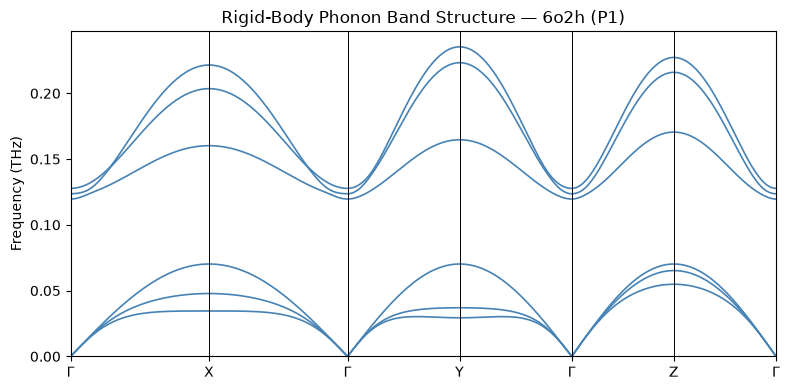

In [12]:
HSP = {'Γ':np.array([0.,0.,0.]),'X':np.array([.5,0.,0.]),
       'Y':np.array([0.,.5,0.]),'Z':np.array([0.,0.,.5])}
path_labels = ['Γ','X','Γ','Y','Γ','Z','Γ']
N_seg = 60

q_frac, tick_idx = [], [0]
for seg in range(len(path_labels)-1):
    p0, p1 = HSP[path_labels[seg]], HSP[path_labels[seg+1]]
    last = (seg == len(path_labels)-2)
    for t in np.linspace(0, 1, N_seg, endpoint=last):
        q_frac.append(p0*(1-t)+p1*t)
    if not last: tick_idx.append(len(q_frac))
tick_idx.append(len(q_frac)-1)

q_frac  = np.array(q_frac)
q_cart  = (B_recip @ q_frac.T).T
freqs_bs = []
for q in q_cart:
    D  = dynamical_matrix(q, unique, K_lab_iso)
    ev = np.linalg.eigvalsh((Msq_inv @ D @ Msq_inv.T).real)
    freqs_bs.append(np.sqrt(np.maximum(ev,0)) * freq_unit)
freqs_bs = np.array(freqs_bs)

x = np.concatenate([[0], np.cumsum(np.linalg.norm(np.diff(q_cart,axis=0),axis=1))])
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(x, freqs_bs, color='steelblue', lw=1.2)
for ti in tick_idx: ax.axvline(x[ti], color='k', lw=0.7)
ax.set_xticks([x[ti] for ti in tick_idx]); ax.set_xticklabels(path_labels)
ax.set_ylabel('Frequency (THz)'); ax.set_xlim(x[0],x[-1]); ax.set_ylim(0)
ax.set_title('Rigid-Body Phonon Band Structure — 6o2h (P1)')
plt.tight_layout(); plt.savefig('band_structure.png', dpi=150); plt.show()


## Diffuse Scattering Maps

$I(\mathbf q) = G^\dagger(\mathbf q)\,D^{-1}(\mathbf q)\,G(\mathbf q)$.
$D(\mathbf q)$ is periodic in the reciprocal lattice, so $D(\mathbf G)=D(\mathbf 0)$
at every Bragg position: the 3 acoustic eigenvalues vanish there, and a
pseudo-inverse (eigenvalues below a small fraction of the largest are
treated as zero) is used to keep $I(\mathbf q)$ finite. Immediately off a
Bragg spot the acoustic branches are linear in $|\delta\mathbf q|$ (their
eigenvalues, proportional to frequency squared, grow as $|\delta\mathbf q|^2$),
producing the $I(\mathbf q)\sim|\mathbf q-\mathbf G|^{-2}$ thermal-diffuse-
scattering halos visible on the log-scale maps below. The elliptical boundary of the map
comes from the circular cutoff $|\mathbf q|<2\pi/d_{\rm min}$ projected onto
the $(h,k)$ plane, which is an ellipse because $|\mathbf b_1|\ne|\mathbf b_2|$
for a triclinic cell.


Computing I(h,k,0) on 177×193 exact q-points (Δh=Δk=1/8=0.1250)...


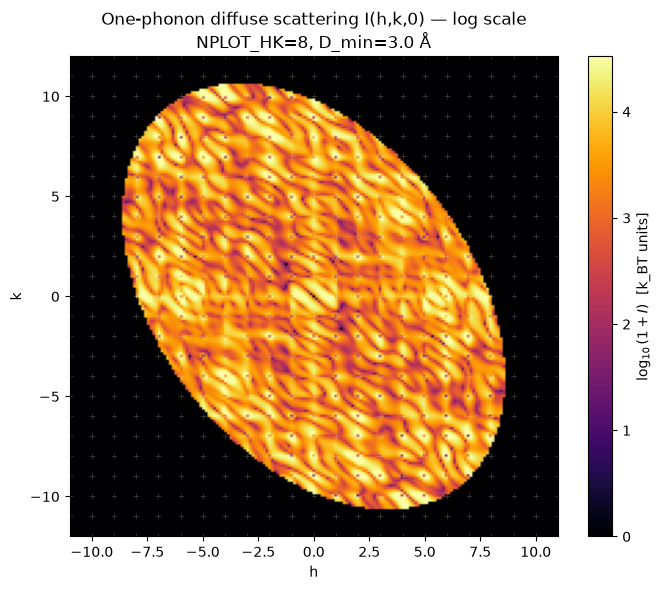

Saved diffuse_map_hk0.png


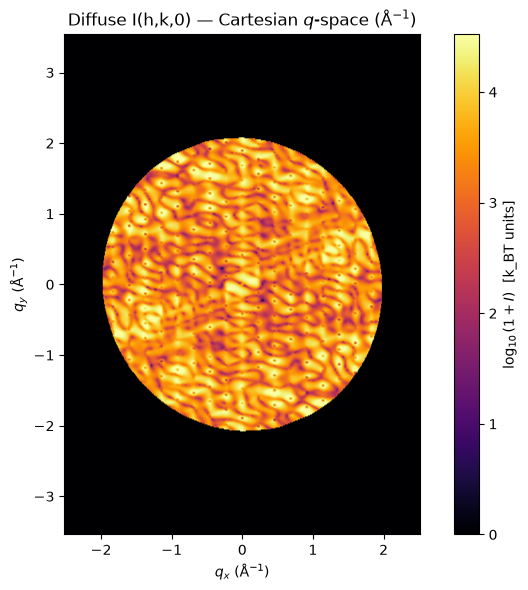

Saved diffuse_map_cart_hk0.png


In [13]:
def safe_diffuse_intensity(G, D, min_eig_frac=1e-6):
    ev, evec = np.linalg.eigh(D.real)
    emax = ev.max()
    if emax < 1e-15: return 0.0
    threshold = min_eig_frac * emax
    pos = ev > threshold
    if not pos.any(): return 0.0
    ev_inv = np.where(pos, 1.0 / np.where(pos, ev, 1.0), 0.0)
    D_inv_G = evec @ (ev_inv * (evec.T @ G.real))
    return float(np.real(G.conj() @ D_inv_G))

def compute_diffuse_map(K_lab, L_layer=0):
    """I(h, k, L_layer) on the exact fine grid (multiples of 1/NPLOT_HK)."""
    h_max = int(np.ceil(cell.a/D_MIN_DIFFUSE))+1
    k_max = int(np.ceil(cell.b/D_MIN_DIFFUSE))+1
    q_cut = 2*np.pi/D_MIN_DIFFUSE
    h_pts = np.arange(-h_max * P, h_max * P + 1) / P
    k_pts = np.arange(-k_max * P, k_max * P + 1) / P
    NH, NK = len(h_pts), len(k_pts)
    print(f"Computing I(h,k,{L_layer}) on {NH}×{NK} exact q-points "
          f"(Δh=Δk=1/{P}={1/P:.4f})...")
    I_map = np.zeros((NH, NK))
    for ih, h in enumerate(h_pts):
        for ik, k in enumerate(k_pts):
            q = h*B_recip[:,0] + k*B_recip[:,1] + L_layer*B_recip[:,2]
            qn = np.linalg.norm(q)
            if qn < 1e-3 or qn > q_cut:
                continue
            G = G_at_hkl(h, k, L_layer)
            D = dynamical_matrix(q, unique, K_lab)
            I_map[ih, ik] = safe_diffuse_intensity(G, D)
    return h_pts, k_pts, I_map, h_max, k_max

def plot_diffuse(h_pts, k_pts, I_map, h_max, k_max, L_layer, fname):
    pos_vals = I_map[I_map > 0]
    if len(pos_vals) == 0:
        print("all I(q) = 0"); return
    vmax = np.percentile(pos_vals, 97)
    I_plot = np.clip(I_map, 0, vmax)

    fig, ax = plt.subplots(figsize=(7,6))
    im = ax.imshow((np.log1p(I_plot) / np.log(10)).T, origin='lower', cmap='inferno',
                   extent=[-h_max, h_max, -k_max, k_max], aspect='auto')
    plt.colorbar(im, ax=ax, label=r'$\log_{10}(1+I)$  [k_BT units]')
    ax.set_xlabel('h'); ax.set_ylabel('k')
    ax.set_title(f'One-phonon diffuse scattering I(h,k,{L_layer}) — log scale\n'
                 f'NPLOT_HK={P}, D_min={D_MIN_DIFFUSE} Å')
    for hi in range(-h_max, h_max+1):
        for ki in range(-k_max, k_max+1):
            if hi == 0 and ki == 0: continue
            ax.plot(hi, ki, '+', color='white', alpha=0.25, markersize=4, markeredgewidth=0.5)
    plt.tight_layout(); plt.savefig(fname, dpi=150); plt.show()
    print(f"Saved {fname}")

def plot_diffuse_cart(h_pts, k_pts, I_map, L_layer, fname_cart, n_grid=500):
    """Same map in Cartesian q-space (Å⁻¹): q = h b1 + k b2 + L b3, projected
    onto (q_x, q_y) and resampled onto a regular grid, for direct comparison
    with an area-detector dataset."""
    H, K = np.meshgrid(h_pts, k_pts, indexing='ij')
    qx_all = H*B_recip[0,0] + K*B_recip[0,1] + L_layer*B_recip[0,2]
    qy_all = H*B_recip[1,0] + K*B_recip[1,1] + L_layer*B_recip[1,2]

    mask   = I_map > 0
    qx, qy, I_vals = qx_all[mask], qy_all[mask], I_map[mask]
    if len(I_vals) < 10:
        print("Too few nonzero points for Cartesian map."); return

    vmax  = np.percentile(I_vals, 97)
    I_log = np.log1p(np.clip(I_vals, 0, vmax)) / np.log(10)
    qx_lin = np.linspace(qx_all.min(), qx_all.max(), n_grid)
    qy_lin = np.linspace(qy_all.min(), qy_all.max(), n_grid)
    QX, QY = np.meshgrid(qx_lin, qy_lin)
    I_cart = griddata((qx, qy), I_log, (QX, QY), method='linear', fill_value=0.0)

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(I_cart, origin='lower', cmap='inferno',
                   extent=[qx_lin[0], qx_lin[-1], qy_lin[0], qy_lin[-1]],
                   aspect='equal')
    plt.colorbar(im, ax=ax, label=r'$\log_{10}(1+I)$  [k_BT units]')
    ax.set_xlabel(r'$q_x$ (Å$^{-1}$)'); ax.set_ylabel(r'$q_y$ (Å$^{-1}$)')
    ax.set_title(f'Diffuse I(h,k,{L_layer}) — Cartesian $q$-space (Å$^{{-1}}$)')
    plt.tight_layout(); plt.savefig(fname_cart, dpi=150); plt.show()
    print(f"Saved {fname_cart}")

h_pts0, k_pts0, I_map0, h_max0, k_max0 = compute_diffuse_map(K_lab_iso, L_layer=0)
plot_diffuse(h_pts0, k_pts0, I_map0, h_max0, k_max0, 0, 'diffuse_map_hk0.png')
plot_diffuse_cart(h_pts0, k_pts0, I_map0, 0, 'diffuse_map_cart_hk0.png')


Computing I(h,k,0.5) on 177×193 exact q-points (Δh=Δk=1/8=0.1250)...


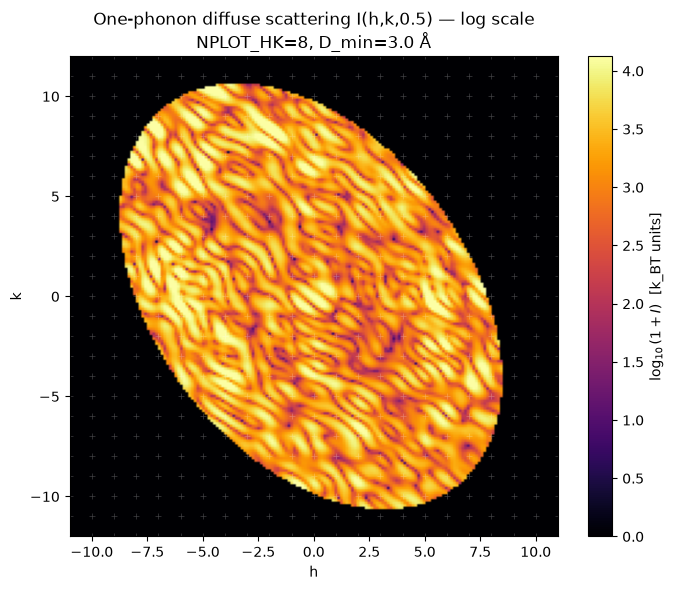

Saved diffuse_map_hk05.png


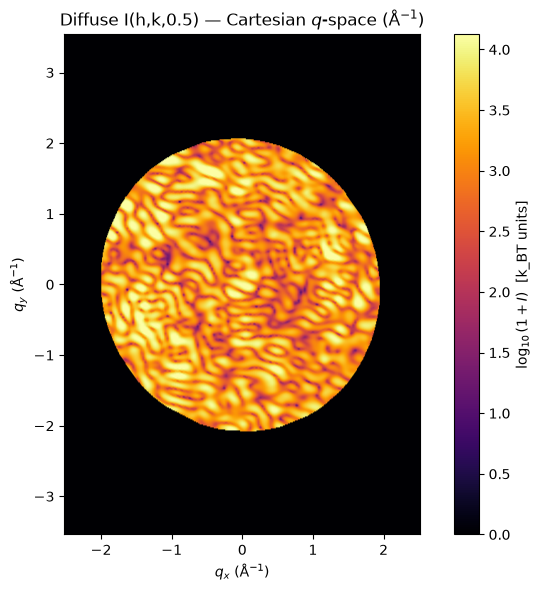

Saved diffuse_map_cart_hk05.png


In [14]:
h_pts5, k_pts5, I_map5, h_max5, k_max5 = compute_diffuse_map(K_lab_iso, L_layer=0.5)
plot_diffuse(h_pts5, k_pts5, I_map5, h_max5, k_max5, 0.5, 'diffuse_map_hk05.png')
plot_diffuse_cart(h_pts5, k_pts5, I_map5, 0.5, 'diffuse_map_cart_hk05.png')


## Synthetic Data

A "true" stiffness is chosen per contact, tied to the number of atom pairs
in that contact (more contacts → a stiffer spring): stiffer along the
contact normal than transverse to it, and with a small but generic
translation–rotation coupling in the local contact frame — i.e. a contact
patch that is not perfectly centred on the frame's own axes, which is the
generic case rather than a special one.

Diffuse intensities are then evaluated at a stratified set of $(h,k,l)$
points: a near-Bragg subset (dominated by the acoustic branches, sensitive
mainly to the long-wavelength elastic limit) and a larger mid-zone subset
(sensitive to the short-range contact stiffnesses individually). Bragg
positions themselves are excluded (I=0 there by construction). Independent
Gaussian noise with a Poisson-like $\sigma\propto\sqrt{I}$ floor is added,
and 15% of the points are held out for cross-validation ($R_{\rm free}$).


In [15]:
def true_Lmap(seed=0):
    rng = np.random.default_rng(seed)
    Lmap = {}
    for c in shell_order:
        n_c   = unique[c]['n_contacts']
        scale = 0.3 + 0.08*n_c
        K = np.zeros((6,6))
        K[0:3,0:3] = scale * np.diag([1.0, 1.3, 0.7])          # rotational block
        K[3:6,3:6] = scale * np.diag([1.0, 1.0, 2.0])          # translational, stiff along contact normal
        coup = 0.15*scale*rng.standard_normal((3,3))           # generic local T-R coupling
        K[0:3,3:6] = coup; K[3:6,0:3] = coup.T
        ev = np.linalg.eigvalsh(K)
        if ev.min() <= 0:
            K += (abs(ev.min()) + 0.05*scale) * np.eye(6)      # keep it physically stable
        Lmap[c] = np.linalg.cholesky(K)
    return Lmap

L_TRUE = true_Lmap(seed=0)
K_LOCAL_TRUE, K_LAB_TRUE = build_K(L_TRUE)
print("True local-frame stiffness eigenvalues per contact (all > 0 required):")
for c in shell_order:
    print(f"  {c}: {np.linalg.eigvalsh(K_LOCAL_TRUE[c]).round(3)}")


True local-frame stiffness eigenvalues per contact (all > 0 required):
  (-1, -1, 0): [1.643 2.82  2.98  3.319 3.874 5.945]
  (-1, 0, -1): [0.915 1.221 1.523 1.754 2.396 3.25 ]
  (-1, 0, 0): [1.75  2.316 2.574 3.259 3.961 5.599]
  (0, -1, 0): [ 3.55   4.514  5.314  5.945  7.355 10.702]
  (0, -1, 1): [0.573 0.834 0.975 1.171 1.46  2.128]
  (0, 0, -1): [2.649 3.204 4.186 5.314 6.917 9.51 ]


In [16]:
def forward_I(K_lab, h, k, l):
    q = h*B_recip[:,0] + k*B_recip[:,1] + l*B_recip[:,2]
    G = G_at_hkl(h, k, l)
    D = dynamical_matrix(q, unique, K_lab)
    v = np.linalg.solve(D, G)
    return float(np.real(np.conj(G) @ v))

def sample_q_points(n_near=60, n_mid=240, seed=1):
    rng = np.random.default_rng(seed)
    q_cut = 2*np.pi/D_MIN_DIFFUSE
    h_max = int(np.ceil(cell.a/D_MIN_DIFFUSE))+1
    k_max = int(np.ceil(cell.b/D_MIN_DIFFUSE))+1

    def snap(h, k):
        return round(h*P)/P, round(k*P)/P

    pts = []
    bragg_centers = [(h0,k0) for h0 in range(-3,4) for k0 in range(-3,4) if (h0,k0)!=(0,0)]
    rng.shuffle(bragg_centers)
    for (h0,k0) in bragg_centers:
        if len(pts) >= n_near: break
        for r in (0.06, 0.12, 0.2):
            ang = rng.uniform(0, 2*np.pi)
            h, k = snap(h0 + r*np.cos(ang), k0 + r*np.sin(ang))
            for l in (0.0, 0.5):
                q = h*B_recip[:,0] + k*B_recip[:,1] + l*B_recip[:,2]
                if 1e-3 < np.linalg.norm(q) < q_cut:
                    pts.append((h,k,l))
    pts = pts[:n_near]

    count = 0
    while count < n_mid:
        h, k = snap(rng.uniform(-h_max, h_max), rng.uniform(-k_max, k_max))
        l = rng.choice([0.0, 0.5])
        q = h*B_recip[:,0] + k*B_recip[:,1] + l*B_recip[:,2]
        qn = np.linalg.norm(q)
        if qn < 1e-3 or qn > q_cut: continue
        if min(abs(h-round(h)), abs(k-round(k))) < 0.05: continue   # skip near-Bragg dark spots
        pts.append((h,k,l)); count += 1
    return np.array(pts)

def well_conditioned(K_lab, h, k, l, min_eig_frac=1e-4):
    """True D(q) is only ever exactly singular at reciprocal-lattice points
    (Section above); a few q-points can still land close enough to a
    near-degenerate direction that the plain (non-pseudo-inverse) solve used
    during refinement is ill-conditioned, so those are screened out here
    rather than included in a fit that assumes a smooth, invertible D(q)."""
    q = h*B_recip[:,0] + k*B_recip[:,1] + l*B_recip[:,2]
    D = dynamical_matrix(q, unique, K_lab)
    ev = np.linalg.eigvalsh(D.real)
    return ev.max() > 0 and ev.min()/ev.max() > min_eig_frac

q_all_raw = sample_q_points()
q_all = np.array([q for q in q_all_raw if well_conditioned(K_LAB_TRUE, *q)])
print(f"{len(q_all)}/{len(q_all_raw)} sampled points kept after the "
      f"conditioning screen ({len(q_all_raw)-len(q_all)} discarded)")
I_true_all = np.array([forward_I(K_LAB_TRUE, *q) for q in q_all])

rng = np.random.default_rng(7)
NOISE_FLOOR, NOISE_SCALE = 0.02, 0.06
sigma_all  = NOISE_FLOOR + NOISE_SCALE*np.sqrt(np.clip(I_true_all, 0, None))
I_obs_all  = I_true_all + rng.normal(0, sigma_all)

train_mask = rng.random(len(q_all)) > 0.15
q_train, I_train, sigma_train = q_all[train_mask], I_obs_all[train_mask], sigma_all[train_mask]
q_test,  I_test,  sigma_test  = q_all[~train_mask], I_obs_all[~train_mask], sigma_all[~train_mask]
w_train = 1.0 / sigma_train**2

print(f"{len(q_all)} q-points sampled: {train_mask.sum()} training, "
      f"{(~train_mask).sum()} held out for R_free")


290/300 sampled points kept after the conditioning screen (10 discarded)
290 q-points sampled: 255 training, 35 held out for R_free


## Where the Fitted q-Points Sit

The sampled points span two Miller-index layers ($l=0$ and $l=0.5$), so they
are not coplanar in $\mathbf q$-space; the left panel shows all of them in
true Cartesian $\mathbf q$ (Å$^{-1}$), and the two right panels show each
layer separately, overlaid on that layer's true diffuse map, so the
near-Bragg and mid-zone sampling is visible relative to the halos.


Computing I(h,k,0.0) on 177×193 exact q-points (Δh=Δk=1/8=0.1250)...
Computing I(h,k,0.5) on 177×193 exact q-points (Δh=Δk=1/8=0.1250)...


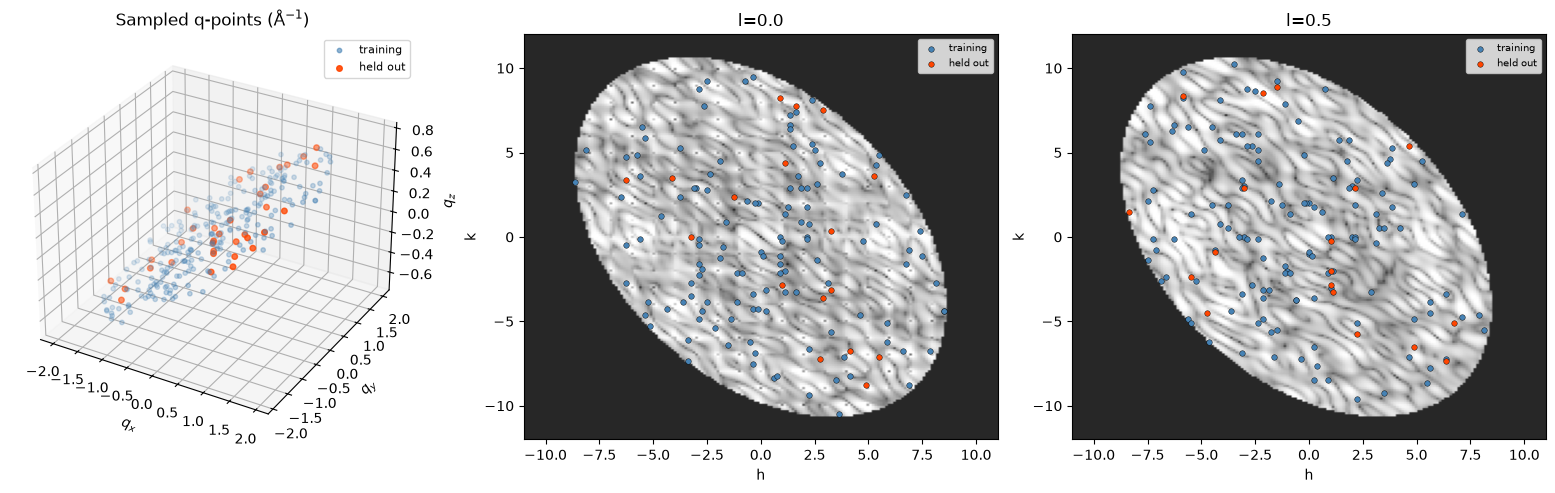

139 points at l=0, 151 points at l=0.5


In [17]:
h_pts_bg0,  k_pts_bg0,  I_bg0,  h_max_bg0,  k_max_bg0  = compute_diffuse_map(K_LAB_TRUE, L_layer=0.0)
h_pts_bg05, k_pts_bg05, I_bg05, h_max_bg05, k_max_bg05 = compute_diffuse_map(K_LAB_TRUE, L_layer=0.5)

def q_cart_of(pts):
    return np.array([h*B_recip[:,0] + k*B_recip[:,1] + l*B_recip[:,2] for h,k,l in pts])

qc_train, qc_test = q_cart_of(q_train), q_cart_of(q_test)

fig = plt.figure(figsize=(16, 5))
ax3d = fig.add_subplot(1, 3, 1, projection='3d')
ax3d.scatter(*qc_train.T, s=10, alpha=0.6, color='steelblue', label='training')
ax3d.scatter(*qc_test.T,  s=16, alpha=0.9, color='orangered', label='held out')
ax3d.set_xlabel('$q_x$'); ax3d.set_ylabel('$q_y$'); ax3d.set_zlabel('$q_z$')
ax3d.set_title('Sampled q-points (Å$^{-1}$)'); ax3d.legend(fontsize=8)

def overlay_panel(ax, h_pts, k_pts, I_bg, h_max, k_max, l_layer):
    pos = I_bg[I_bg > 0]
    vmax = np.percentile(pos, 97) if len(pos) else 1.0
    ax.imshow((np.log1p(np.clip(I_bg, 0, vmax)) / np.log(10)).T, origin='lower', cmap='gray',
              extent=[-h_max, h_max, -k_max, k_max], aspect='auto', alpha=0.85)
    for pts, color, label in [(q_train, 'steelblue', 'training'), (q_test, 'orangered', 'held out')]:
        sel = np.abs(pts[:,2] - l_layer) < 1e-6
        ax.scatter(pts[sel,0], pts[sel,1], s=16, color=color, edgecolor='k',
                  linewidth=0.3, label=label)
    ax.set_xlabel('h'); ax.set_ylabel('k'); ax.set_title(f'l={l_layer}')
    ax.legend(fontsize=7, loc='upper right')

overlay_panel(fig.add_subplot(1,3,2), h_pts_bg0,  k_pts_bg0,  I_bg0,  h_max_bg0,  k_max_bg0,  0.0)
overlay_panel(fig.add_subplot(1,3,3), h_pts_bg05, k_pts_bg05, I_bg05, h_max_bg05, k_max_bg05, 0.5)

plt.tight_layout(); plt.savefig('sampled_q_points.png', dpi=150); plt.show()
print(f"{(q_all[:,2]==0.0).sum()} points at l=0, {(q_all[:,2]==0.5).sum()} points at l=0.5")


## Refining $K$ to the Synthetic Data

The objective is a weighted least-squares fit plus the local-frame
regularizer, minimized over the Cholesky factors $\{L_{\mathbf n}\}$:

$$\mathcal L(\theta) = \sum_{\mathbf q\in\rm train} w(\mathbf q)
\bigl[I_{\rm obs}(\mathbf q)-I_{\rm model}(\mathbf q;\theta)\bigr]^2
+ \lambda\sum_{\mathbf n}\bigl\|K_{\mathbf n}^{\rm local}[\Omega,v]\bigr\|_F^2$$

**Gradient.** Since $I=G^\dagger D^{-1}G$ and $d(D^{-1})=-D^{-1}\,dD\,D^{-1}$,
$dI = -v^\dagger\,dD\,v$ with $v=D^{-1}G$. Because $D$ is linear in each
contact's $K_{\mathbf n}$, $dD$ is a known linear function of $dK_{\mathbf n}$,
giving a closed-form $dI/dK_{\mathbf n}$ at essentially no extra cost beyond
the forward evaluation; the chain rule through the fixed lab-frame transform
and the Cholesky factor $K=LL^{\mathsf T}$ then gives $d\mathcal L/dL$
directly (verified below against finite differences).

**Optimizer.** L-BFGS-B with the analytic gradient above. The Cholesky
parameterization makes every point in parameter space a physically stable
model (Section above), so the optimizer runs over $\mathbb R^{126}$
unconstrained rather than needing inequality constraints on $K$; with exact
gradients in hand, a quasi-Newton method converges in far fewer iterations
than a derivative-free or finite-difference approach would need, and no
global/stochastic search (basin-hopping, CMA-ES) is warranted for a smooth,
unconstrained, well-conditioned objective like this one. The training
q-points are chosen away from Bragg positions, so $D(\mathbf q)$ is
comfortably invertible there and a plain solve (rather than the
diffuse-map's pseudo-inverse) is used, keeping the objective smooth.


In [18]:
def loss_and_grad(theta, q_list, I_obs, weights):
    Lmap = theta_to_Lmap(theta)
    K_local, K_lab = build_K(Lmap)
    grad_L = {c: np.zeros((6,6)) for c in shell_order}
    data_loss = 0.0

    Gamma_full = {c: np.block([[unique[c]['R_frame'], np.zeros((3,3))],
                               [np.zeros((3,3)), unique[c]['R_frame']]])
                  for c in shell_order}
    N_mat = {c: Gc_inv_matrix(unique[c]['c_local']) @ Gamma_full[c].T
             for c in shell_order}

    for (h,k,l), Iobs, wq in zip(q_list, I_obs, weights):
        q = h*B_recip[:,0] + k*B_recip[:,1] + l*B_recip[:,2]
        G = G_at_hkl(h,k,l)
        D = dynamical_matrix(q, unique, K_lab)
        v = np.linalg.solve(D, G)
        Imodel = float(np.real(np.conj(G) @ v))
        resid  = Imodel - Iobs
        data_loss += wq * resid**2
        coeff = 2.0 * wq * resid

        for c in shell_order:
            R_n = unique[c]['R_n']
            A_n = ad_translation(R_n)
            pn   = np.exp(1j * q @ R_n); pneg = np.conj(pn)
            u  = A_n @ v
            w1 = (A_n - pn*np.eye(6)) @ v
            w2 = (np.eye(6) - A_n*pneg) @ v
            Graw = -(np.outer(u.conj(), w1) + np.outer(v.conj(), w2))
            G_A  = N_mat[c] @ Graw @ N_mat[c].T
            dL_c = np.real((G_A + G_A.T) @ Lmap[c])
            grad_L[c] += coeff * dL_c

    reg = regularizer(K_local)
    for c in shell_order:
        TR = K_local[c][0:3, 3:6]
        Graw_reg = np.zeros((6,6)); Graw_reg[0:3, 3:6] = 2*LAMBDA_REG*TR
        grad_L[c] += (Graw_reg + Graw_reg.T) @ Lmap[c]
        grad_L[c] = np.tril(grad_L[c])

    return data_loss + reg, Lmap_to_theta(grad_L)


In [19]:
# Gradient check: analytic vs. central finite differences, a handful of
# random parameter directions on a small q-subset.
rng_chk = np.random.default_rng(42)
theta_chk = Lmap_to_theta(isotropic_Lmap()) + 0.05*rng_chk.standard_normal(N_PARAMS)
q_chk, I_chk, w_chk = q_train[:15], I_train[:15], w_train[:15]

loss0, grad0 = loss_and_grad(theta_chk, q_chk, I_chk, w_chk)
eps = 1e-6
errs = []
for idx in rng_chk.choice(N_PARAMS, size=8, replace=False):
    tp = theta_chk.copy(); tp[idx] += eps
    tm = theta_chk.copy(); tm[idx] -= eps
    fd = (loss_and_grad(tp, q_chk, I_chk, w_chk)[0]
          - loss_and_grad(tm, q_chk, I_chk, w_chk)[0]) / (2*eps)
    errs.append(abs(fd - grad0[idx]) / max(abs(fd), 1e-6))
print(f"Gradient check, max relative error over 8 random directions: {max(errs):.2e}")


Gradient check, max relative error over 8 random directions: 3.59e-06


In [20]:
theta0 = Lmap_to_theta(isotropic_Lmap())
theta_history = [theta0.copy()]   # one snapshot per L-BFGS-B iteration, for the convergence movie below

result = minimize(loss_and_grad, theta0, args=(q_train, I_train, w_train),
                   jac=True, method='L-BFGS-B',
                   options={'maxiter': 1000, 'ftol': 1e-12, 'gtol': 1e-10},
                   callback=lambda xk: theta_history.append(xk.copy()))
print(result.message, ' iterations:', result.nit, ' final loss:', result.fun)

theta_fit = result.x
_, K_LAB_FIT = build_K(theta_to_Lmap(theta_fit))


STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT  iterations: 1000  final loss: 165.58010730340555


## Watching the Band Structure Converge

The true band structure (from $K_{\rm true}$) is drawn as a thick grey line
along the same Γ–X–Γ–Y–Γ–Z–Γ path used above; the colored line is the band
structure of the current Cholesky parameters at each L-BFGS-B iteration, so
the GIF shows the fit converging onto the true dispersion mode by mode.
Only band structures are recomputed per frame (a few hundred $6\times6$
eigenproblems each — cheap), never the full diffuse map, and frames are
rasterized and discarded one at a time rather than held in memory, so the
whole movie is inexpensive even with many iterations. Because the diffuse
signal is dominated by the acoustic branches (Section above), expect the
low-frequency bands near Γ to lock onto the true curve quickly while the
optical bands — which contribute far less to $I(\mathbf q)$ — converge
more slowly or less completely.


In [21]:
def bandstructure_freqs(K_lab):
    freqs = []
    for q in q_cart:
        D  = dynamical_matrix(q, unique, K_lab)
        ev = np.linalg.eigvalsh((Msq_inv @ D @ Msq_inv.T).real)
        freqs.append(np.sqrt(np.maximum(ev, 0)) * freq_unit)
    return np.array(freqs)

freqs_true_bs = bandstructure_freqs(K_LAB_TRUE)
ymax = freqs_true_bs.max() * 1.15

frame_idx = np.unique(np.linspace(0, len(theta_history)-1,
                                  min(60, len(theta_history))).astype(int))

legend_handles = [Line2D([0], [0], color='0.6', lw=3.5, label='Ground truth'),
                  Line2D([0], [0], color='steelblue', lw=1.3, label='Current fit')]

images_bs = []
for fi in frame_idx:
    _, K_lab_fi = build_K(theta_to_Lmap(theta_history[fi]))
    freqs_fi = bandstructure_freqs(K_lab_fi)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x, freqs_true_bs, color='0.6', lw=3.5, zorder=1)     # 6 bands, one legend entry
    ax.plot(x, freqs_fi, color='steelblue', lw=1.3, zorder=2)
    for ti in tick_idx: ax.axvline(x[ti], color='k', lw=0.7)
    ax.set_xticks([x[ti] for ti in tick_idx]); ax.set_xticklabels(path_labels)
    ax.set_ylabel('Frequency (THz)'); ax.set_xlim(x[0], x[-1]); ax.set_ylim(0, ymax)
    ax.set_title(f'Band-structure convergence — iteration {fi}/{len(theta_history)-1}')
    ax.legend(handles=legend_handles, loc='upper right', fontsize=8)
    plt.tight_layout()
    images_bs.append(fig_to_image(fig))
    plt.close(fig)

imageio.mimsave('band_structure_convergence.gif', images_bs, fps=8, loop=0)
del images_bs; gc.collect()
print(f"Saved band_structure_convergence.gif ({len(frame_idx)} frames from "
      f"{len(theta_history)} iterations)")


Saved band_structure_convergence.gif (60 frames from 1001 iterations)


R (training set):  0.0006
R_free (held out): 0.0008


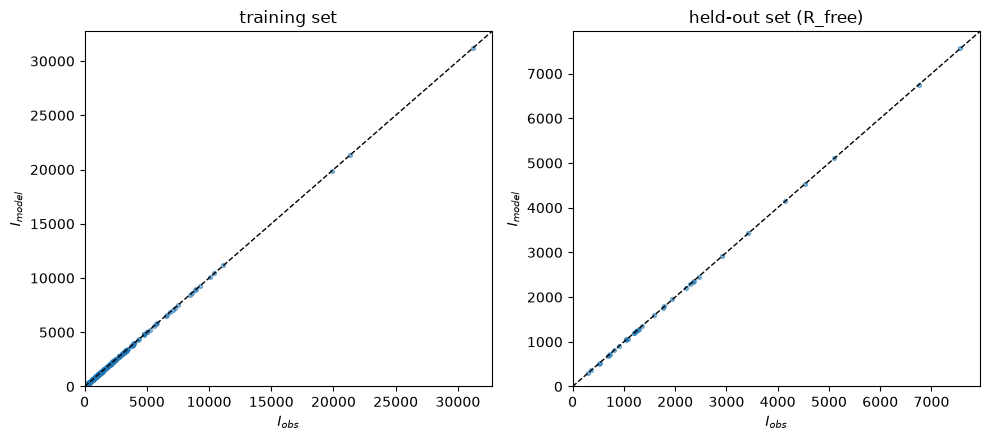

In [22]:
def R_factor(K_lab, q_list, I_list):
    Imodel = np.array([forward_I(K_lab, *q) for q in q_list])
    return np.sum(np.abs(Imodel - I_list)) / np.sum(np.abs(I_list)), Imodel

R_train, I_model_train = R_factor(K_LAB_FIT, q_train, I_train)
R_free,  I_model_test  = R_factor(K_LAB_FIT, q_test,  I_test)
print(f"R (training set):  {R_train:.4f}")
print(f"R_free (held out): {R_free:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10,4.5))
for ax, Im, Io, title in [(axes[0], I_model_train, I_train, 'training set'),
                          (axes[1], I_model_test,  I_test,  'held-out set (R_free)')]:
    ax.scatter(Io, Im, s=8, alpha=0.5)
    lim = [0, max(Io.max(), Im.max())*1.05]
    ax.plot(lim, lim, 'k--', lw=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('$I_{obs}$'); ax.set_ylabel('$I_{model}$'); ax.set_title(title)
plt.tight_layout(); plt.savefig('refinement_fit_quality.png', dpi=150); plt.show()


## Synthetic vs. Fitted Diffuse Scattering

The full diffuse map recomputed from the true and fitted stiffnesses, side
by side. The refinement above only ever saw `I_train` at the sampled
q-points; this map compares the two models everywhere, including regions
with no training data nearby.

The true/fitted maps above are plotted as $\log_{10}(1+I)$, like the maps
earlier in the notebook, but the two residual panels below are **not**
log-transformed. The absolute-residual colorbar is literally
$I_{\rm fit}-I_{\rm true}$ in the same untransformed intensity units as
$I$ itself (a value of, say, 8 there means $\Delta I = 8$, not $e^8$) — and
because $I$ itself spans many orders of magnitude between the acoustic
halos and the weak mid-zone signal, that residual is dominated by whatever
happens right at the brightest halo pixels even when the fit is good
everywhere else. The relative-residual panel,
$(I_{\rm fit}-I_{\rm true})/I_{\rm true}$ clipped to $\pm100\%$, corrects
for that by dividing out the local intensity scale, so a good fit in the
faint mid-zone regions shows up clearly instead of being swamped by the
peak-height mismatch near the halos.


Computing I(h,k,0) on 177×193 exact q-points (Δh=Δk=1/8=0.1250)...


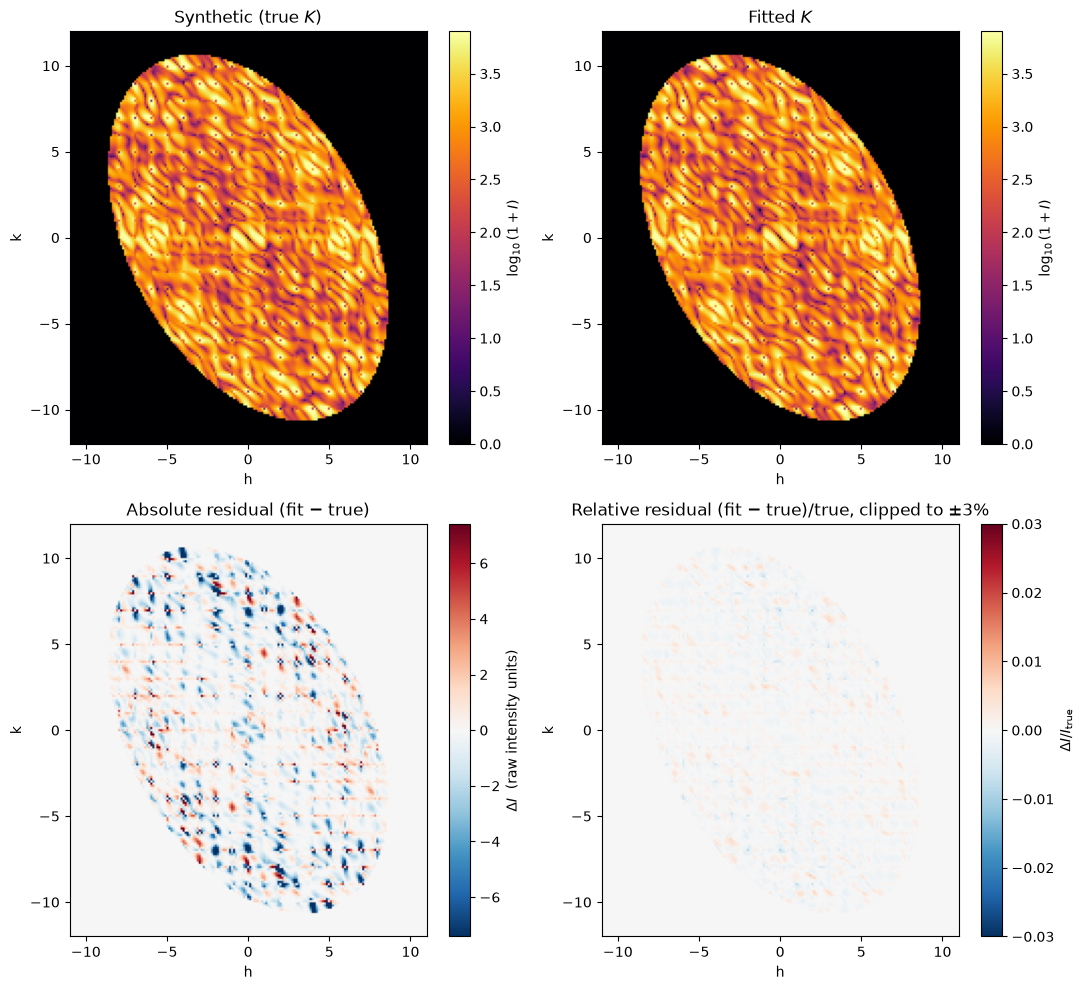

Saved diffuse_map_true_vs_fit_hk0.png
Absolute residual RMS: 1.853  (I_true RMS: 2521)
Relative residual, unclipped — median |·|: 8.99e-06, 90th pct |·|: 0.00122


In [23]:
h_pts_cmp, k_pts_cmp, I_true_map, h_max_cmp, k_max_cmp = h_pts_bg0, k_pts_bg0, I_bg0, h_max_bg0, k_max_bg0
_, _, I_fit_map, _, _ = compute_diffuse_map(K_LAB_FIT, L_layer=0)

def plot_diffuse_comparison(h_pts, k_pts, I_true, I_fit, h_max, k_max, fname, rel_clip=1.0):
    pos_vals = np.concatenate([I_true[I_true > 0], I_fit[I_fit > 0]])
    vmax = np.percentile(pos_vals, 97) if len(pos_vals) else 1.0
    resid = I_fit - I_true
    rmax = np.percentile(np.abs(resid), 99) if np.any(resid) else 1.0

    # Relative residual: divides out the intensity scale so the (very bright)
    # near-Bragg acoustic halos don't dominate the comparison the way they do
    # in the absolute residual. A small floor avoids dividing by ~0 near the
    # dark Bragg spots themselves.
    floor = 0.02 * vmax
    rel = resid / np.maximum(I_true, floor)
    rel_disp = np.clip(rel, -rel_clip, rel_clip)

    extent = [-h_max, h_max, -k_max, k_max]
    fig, axes = plt.subplots(2, 2, figsize=(11, 10))

    im0 = axes[0,0].imshow((np.log1p(np.clip(I_true, 0, vmax)) / np.log(10)).T, origin='lower',
                           cmap='inferno', extent=extent, aspect='auto')
    axes[0,0].set_title('Synthetic (true $K$)')
    plt.colorbar(im0, ax=axes[0,0], label=r'$\log_{10}(1+I)$')

    im1 = axes[0,1].imshow((np.log1p(np.clip(I_fit, 0, vmax)) / np.log(10)).T, origin='lower',
                           cmap='inferno', extent=extent, aspect='auto')
    axes[0,1].set_title('Fitted $K$')
    plt.colorbar(im1, ax=axes[0,1], label=r'$\log_{10}(1+I)$')

    im2 = axes[1,0].imshow(resid.T, origin='lower', cmap='RdBu_r',
                           extent=extent, aspect='auto', vmin=-rmax, vmax=rmax)
    axes[1,0].set_title('Absolute residual (fit − true)')
    plt.colorbar(im2, ax=axes[1,0], label='$\\Delta I$  (raw intensity units)')

    im3 = axes[1,1].imshow(rel_disp.T, origin='lower', cmap='RdBu_r',
                           extent=extent, aspect='auto', vmin=-rel_clip, vmax=rel_clip)
    axes[1,1].set_title(f'Relative residual (fit − true)/true, clipped to ±{100*rel_clip:.0f}%')
    plt.colorbar(im3, ax=axes[1,1], label='$\\Delta I / I_{\\rm true}$')

    for ax in axes.flat:
        ax.set_xlabel('h'); ax.set_ylabel('k')
    plt.tight_layout(); plt.savefig(fname, dpi=150); plt.show()

    rms_resid = np.sqrt(np.mean(resid**2))
    rms_true  = np.sqrt(np.mean(I_true**2))
    print(f"Saved {fname}")
    print(f"Absolute residual RMS: {rms_resid:.4g}  (I_true RMS: {rms_true:.4g})")
    print(f"Relative residual, unclipped — median |·|: {np.median(np.abs(rel)):.3g}, "
          f"90th pct |·|: {np.percentile(np.abs(rel), 90):.3g}")

plot_diffuse_comparison(h_pts_cmp, k_pts_cmp, I_true_map, I_fit_map, h_max_cmp, k_max_cmp,
                        'diffuse_map_true_vs_fit_hk0.png', 0.03)


## Predicted Atomic Displacement Parameters

The single-cell generalized-coordinate covariance
$\Sigma=\langle(\Omega,v)(\Omega,v)^{\mathsf T}\rangle$ follows from
integrating $D(\mathbf q)^{-1}=\sum_s e_s(\mathbf q)e_s(\mathbf q)^{\mathsf T}
/\omega_s^2(\mathbf q)$ over the Brillouin zone (with the same eigenvalue
floor used elsewhere, to drop the acoustic zero modes at $\mathbf q=0$).
Projecting onto an atom at position $\mathbf r$ via
$\delta\mathbf r = v+\Omega\times(\mathbf r-\mathbf r_{\rm cm})$ gives that
atom's full $3\times3$ anisotropic displacement tensor
$U=J\Sigma J^{\mathsf T}$ — the same object a crystallographic ANISOU record
holds — with the familiar isotropic $B=\tfrac{8\pi^2}{3}\mathrm{Tr}(U)$ as
its trace.

Both the true and fitted synthetic models are already in the same reduced
($k_BT=1$) units, so an atom-by-atom comparison of either $B$ or the full
tensor $U$ is meaningful on an absolute scale, and is the direct measure of
how well the refinement recovered the underlying dynamics, residue by
residue. The deposited structure's own ADPs are shown separately: some
depositions include full ANISOU records (checked below), and 6o2h's
isotropic $B$-factors are always available, but comparing them to our
arbitrarily-chosen synthetic $K$ on an absolute scale is not meaningful —
only once $K$ is fit to real diffuse data would that comparison be direct.


In [24]:
def bz_covariance(K_lab, n_grid=12, eig_floor_frac=1e-6):
    Sigma = np.zeros((6,6))
    grid = np.arange(n_grid) / n_grid
    n_tot = 0
    for i in grid:
        for j in grid:
            for k in grid:
                q = B_recip @ np.array([i, j, k])
                D  = dynamical_matrix(q, unique, K_lab)
                Dw = Msq_inv @ D @ Msq_inv.T
                ev, evec = np.linalg.eigh(Dw.real)
                thresh = eig_floor_frac * max(ev.max(), 1e-12)
                e_lab = Msq_inv.T @ evec
                for s in range(6):
                    if ev[s] > thresh:
                        Sigma += np.outer(e_lab[:, s], e_lab[:, s]) / ev[s]
                n_tot += 1
    return Sigma / n_tot

def atom_adp_tensors(Sigma, positions):
    """Full anisotropic displacement tensor U (Å², 3x3) per atom."""
    U = np.zeros((len(positions), 3, 3))
    for i, r in enumerate(positions):
        d = r - r_cm_at
        Jr = np.zeros((3,6)); Jr[:,0:3] = -skew(d); Jr[:,3:6] = np.eye(3)
        U[i] = Jr @ Sigma @ Jr.T
    return U

def isotropic_B(U):
    return (8*np.pi**2/3) * np.trace(U, axis1=1, axis2=2)

Sigma_true = bz_covariance(K_LAB_TRUE)
Sigma_fit  = bz_covariance(K_LAB_FIT)
U_true = atom_adp_tensors(Sigma_true, apos)
U_fit  = atom_adp_tensors(Sigma_fit,  apos)
B_true, B_fit = isotropic_B(U_true), isotropic_B(U_fit)
print(f"Mean predicted B (true K):  {B_true.mean():.2f} Å²")
print(f"Mean predicted B (fit K):   {B_fit.mean():.2f} Å²")
print(f"Mean deposited B (6o2h):    {b_exp.mean():.2f} Å²")


Mean predicted B (true K):  3.28 Å²
Mean predicted B (fit K):   3.28 Å²
Mean deposited B (6o2h):    13.11 Å²


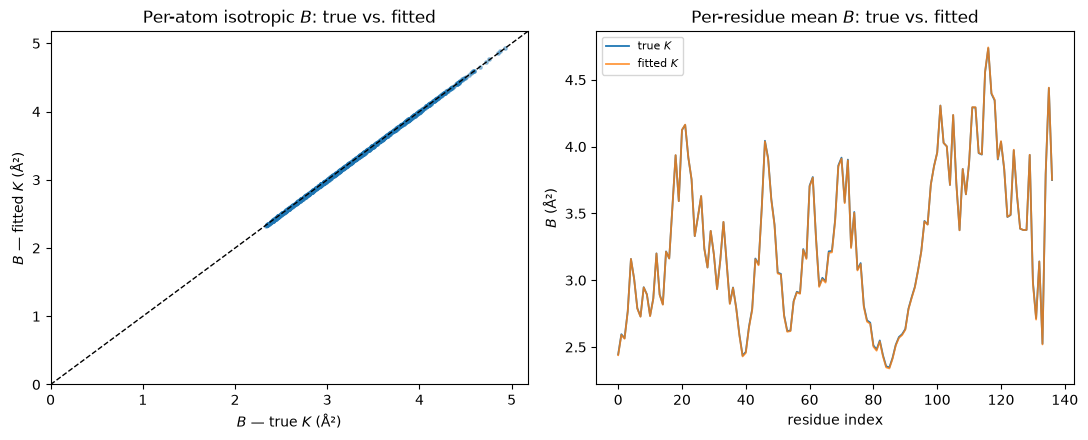

In [25]:
# Per-residue means, compared directly (true vs. fitted, same units)
res_ids = []
for ch in st[0]:
    for res in ch:
        for atom in res:
            res_ids.append((ch.name, res.seqid.num))
res_index = {}
res_inverse = np.empty(len(res_ids), dtype=int)
for i, key in enumerate(res_ids):
    res_inverse[i] = res_index.setdefault(key, len(res_index))
n_res = len(res_index)
def per_residue_mean(x):
    out = np.zeros(n_res)
    counts = np.zeros(n_res)
    for v, r in zip(x, res_inverse):
        out[r] += v; counts[r] += 1
    return out / counts

B_true_res, B_fit_res = per_residue_mean(B_true), per_residue_mean(B_fit)

fig, axes = plt.subplots(1, 2, figsize=(11,4.5))

ax = axes[0]
ax.scatter(B_true, B_fit, s=6, alpha=0.4)
lim = [0, max(B_true.max(), B_fit.max())*1.05]
ax.plot(lim, lim, 'k--', lw=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('$B$ — true $K$ (Å²)'); ax.set_ylabel('$B$ — fitted $K$ (Å²)')
ax.set_title('Per-atom isotropic $B$: true vs. fitted')

ax = axes[1]
ax.plot(B_true_res, label='true $K$', lw=1.3)
ax.plot(B_fit_res, label='fitted $K$', lw=1.3, alpha=0.8)
ax.set_xlabel('residue index'); ax.set_ylabel('$B$ (Å²)')
ax.set_title('Per-residue mean $B$: true vs. fitted')
ax.legend(fontsize=8)

plt.tight_layout(); plt.savefig('adp_comparison.png', dpi=150); plt.show()


### Anisotropic Comparison

The isotropic trace above discards the shape of each atom's displacement
ellipsoid. The full tensor comparison below checks whether the refinement
also recovers that shape: the six independent components of $U$ plotted
against each other (true vs. fitted, pooled over all atoms), and each
atom's anisotropy ratio (largest/smallest principal displacement) — a
model that only matches on the isotropic trace but gets the anisotropy
wrong would show good agreement in the $B$-factor plots above but poor
agreement here.


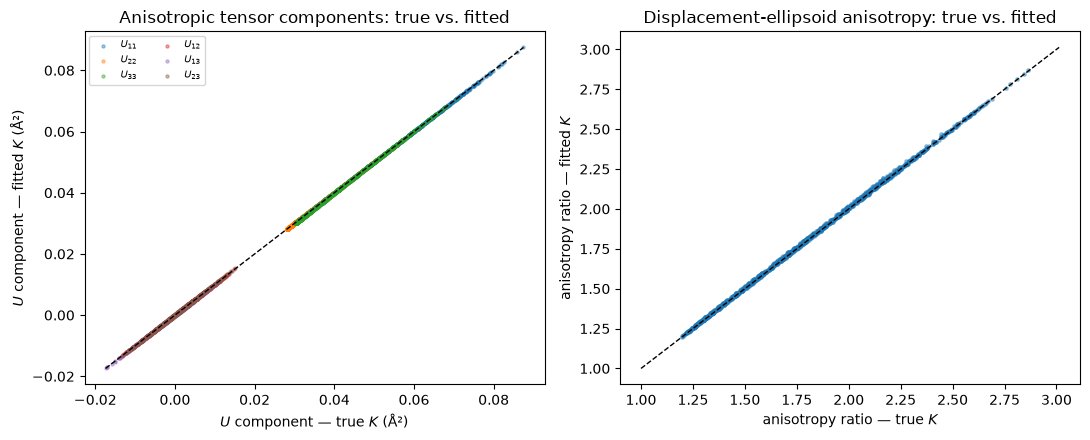

In [26]:
def anisotropy_ratio(U):
    ev = np.linalg.eigvalsh(U)
    return ev[:, -1] / np.clip(ev[:, 0], 1e-12, None)

comp_idx   = [(0,0),(1,1),(2,2),(0,1),(0,2),(1,2)]
comp_names = ['$U_{11}$','$U_{22}$','$U_{33}$','$U_{12}$','$U_{13}$','$U_{23}$']

fig, axes = plt.subplots(1, 2, figsize=(11,4.5))

ax = axes[0]
for (i,j), name in zip(comp_idx, comp_names):
    ax.scatter(U_true[:,i,j], U_fit[:,i,j], s=5, alpha=0.4, label=name)
lim = [min(U_true.min(), U_fit.min()), max(U_true.max(), U_fit.max())]
ax.plot(lim, lim, 'k--', lw=1)
ax.set_xlabel('$U$ component — true $K$ (Å²)'); ax.set_ylabel('$U$ component — fitted $K$ (Å²)')
ax.set_title('Anisotropic tensor components: true vs. fitted')
ax.legend(fontsize=7, ncol=2)

ax = axes[1]
aniso_true, aniso_fit = anisotropy_ratio(U_true), anisotropy_ratio(U_fit)
ax.scatter(aniso_true, aniso_fit, s=6, alpha=0.4)
lim2 = [1, max(aniso_true.max(), aniso_fit.max())*1.05]
ax.plot(lim2, lim2, 'k--', lw=1)
ax.set_xlabel('anisotropy ratio — true $K$'); ax.set_ylabel('anisotropy ratio — fitted $K$')
ax.set_title('Displacement-ellipsoid anisotropy: true vs. fitted')

plt.tight_layout(); plt.savefig('adp_anisotropic_comparison.png', dpi=150); plt.show()


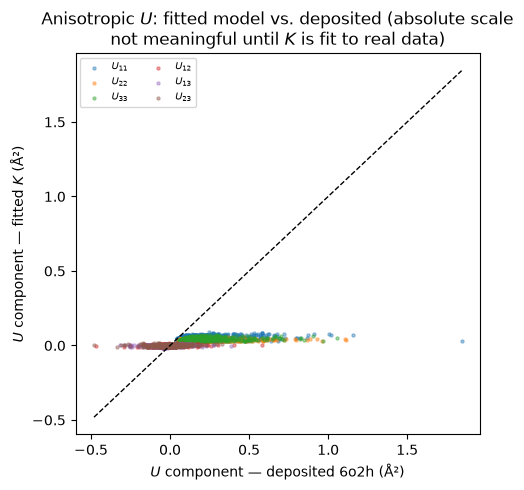

In [27]:
# Deposited ANISOU comparison, when present: this is the comparison that
# becomes meaningful once K is fit to real (not synthetic) diffuse data.
if has_aniso.mean() > 0.5:
    fig, ax = plt.subplots(figsize=(5,5))
    for (i,j), name in zip(comp_idx, comp_names):
        ax.scatter(u_exp[has_aniso,i,j], U_fit[has_aniso,i,j], s=5, alpha=0.4, label=name)
    lim = [min(u_exp[has_aniso].min(), U_fit[has_aniso].min()),
           max(u_exp[has_aniso].max(), U_fit[has_aniso].max())]
    ax.plot(lim, lim, 'k--', lw=1)
    ax.set_xlabel('$U$ component — deposited 6o2h (Å²)')
    ax.set_ylabel('$U$ component — fitted $K$ (Å²)')
    ax.set_title('Anisotropic $U$: fitted model vs. deposited (absolute scale\n'
                 'not meaningful until $K$ is fit to real data)')
    ax.legend(fontsize=7, ncol=2)
    plt.tight_layout(); plt.savefig('adp_vs_deposited_anisotropic.png', dpi=150); plt.show()
else:
    print(f"Only {has_aniso.mean():.1%} of atoms in 6o2h carry ANISOU records "
          f"(full anisotropic refinement typically needs atomic resolution); "
          f"skipping the deposited anisotropic comparison. Isotropic B-factors "
          f"are compared above regardless.")


## Phonon Mode Visualization

Each phonon mode at a chosen $\mathbf q$-point is rendered as a looping GIF
of the rigid-body motion, using the fitted model. $|\Omega|$ and $|v|$ are
the rotational and translational norms of the mass-weighted eigenvector
(normalized so $\Omega^{\mathsf T}J\Omega+v^{\mathsf T}mv=1$); their ratio
gives the rotational kinetic-energy fraction, used below to label each mode
librational, translational, or mixed. Displacement amplitude is defined as
the largest per-atom displacement in Å, not the center-of-mass displacement.


In [28]:
Q_VIZ     = np.array([0.5, 0.25, 0.0])  # fractional — zone-boundary, off-axis
AMPLITUDE = 3.0    # Å — maximum per-atom displacement
N_FRAMES  = 30
GIF_FPS   = 12

q_viz  = B_recip @ Q_VIZ
D_viz  = dynamical_matrix(q_viz, unique, K_LAB_FIT)
Dw_viz = (Msq_inv @ D_viz @ Msq_inv.T).real
ev_v, evec_v = np.linalg.eigh(Dw_viz)
ev_v      = np.maximum(ev_v, 0)
freqs_viz = np.sqrt(ev_v) * freq_unit
evecs_lab = Msq_inv.T @ evec_v

print(f"Modes at q={Q_VIZ}:")
hdr = f"{'Mode':>5} {'Freq (THz)':>14} {'|Ω|':>9} {'|v|':>9}  {'rot KE %':>9}  character"
print(hdr); print('-'*len(hdr))
for s in range(6):
    Om = evecs_lab[:3, s].real; v = evecs_lab[3:, s].real
    rot_KE, trans_KE = float(Om @ J @ Om), float(m_total * (v@v))
    rot_pct = 100 * rot_KE / max(rot_KE + trans_KE, 1e-30)
    char = 'librational' if rot_pct > 60 else ('translational' if rot_pct < 40 else 'mixed')
    print(f"  {s:3d}  {freqs_viz[s]:14.6f}  {np.linalg.norm(Om):9.4f}  "
          f"{np.linalg.norm(v):9.4f}  {rot_pct:9.1f}%  {char}")


Modes at q=[0.5  0.25 0.  ]:
 Mode     Freq (THz)       |Ω|       |v|   rot KE %  character
--------------------------------------------------------------
    0        0.097593     0.0002     0.0077        8.2%  translational
    1        0.128994     0.0002     0.0079        4.7%  translational
    2        0.141849     0.0000     0.0081        0.1%  translational
    3        0.301829     0.0006     0.0004       99.8%  librational
    4        0.309159     0.0006     0.0023       91.8%  librational
    5        0.382038     0.0008     0.0017       95.4%  librational


In [29]:
# Molecular isosurface: marching cubes on the hybrid model density, downsampled
# for speed, keeping only the largest connected component so periodic-image
# and solvent-void fragments are discarded, then Lambert-shaded per face so
# shape and roughness stay visible even at partial transparency.
base_pos = apos.copy()
pts_cm   = base_pos - r_cm_at

MC_DS = 0.5
rho_mc = nd_zoom(rho_model.astype(np.float32), MC_DS, order=1)
nu_mc, nv_mc, nw_mc = rho_mc.shape
_iso_level = rho_mc.max() * 0.05
mc_verts_grid, mc_faces_raw, _normals, _vals = marching_cubes(rho_mc, level=_iso_level)
_frac = mc_verts_grid / np.array([nu_mc, nv_mc, nw_mc])
mc_verts_raw = (A_orth @ _frac.T).T

def _largest_component(verts, faces):
    n = len(verts)
    idx_i = np.concatenate([faces[:,0], faces[:,1], faces[:,2]])
    idx_j = np.concatenate([faces[:,1], faces[:,2], faces[:,0]])
    adj   = csr_matrix((np.ones(len(idx_i), dtype=np.int8), (idx_i, idx_j)), shape=(n, n))
    _, labels = sc_connected_components(adj, directed=False)
    keep_label = np.bincount(labels).argmax()
    keep = np.where(labels == keep_label)[0]
    remap = np.full(n, -1, dtype=int); remap[keep] = np.arange(len(keep))
    face_ok = (labels[faces] == keep_label).all(axis=1)
    return verts[keep], remap[faces[face_ok]]

mc_verts_cart, mc_faces = _largest_component(mc_verts_raw, mc_faces_raw)
mc_verts_cm = mc_verts_cart - r_cm_at
print(f"Isosurface: {len(mc_verts_cm)} verts, {len(mc_faces)} tris "
      f"(largest connected component, level={_iso_level:.3f} e/Å³)")

_LIGHT = np.array([0.5, 0.8, 1.0]); _LIGHT /= np.linalg.norm(_LIGHT)

def _shade(tri_array, hex_color, alpha, ambient=0.35):
    v0, v1, v2 = tri_array[:,0], tri_array[:,1], tri_array[:,2]
    n = np.cross(v1 - v0, v2 - v0)
    mag = np.linalg.norm(n, axis=1, keepdims=True)
    n /= np.where(mag > 1e-12, mag, 1.0)
    intensity = ambient + (1 - ambient) * np.abs(n @ _LIGHT)
    r = int(hex_color[1:3], 16) / 255
    g = int(hex_color[3:5], 16) / 255
    b = int(hex_color[5:7], 16) / 255
    return np.column_stack([intensity*r, intensity*g, intensity*b, np.full(len(tri_array), alpha)])

def displaced_mc(mode_idx, scale):
    Om_raw = evecs_lab[:3, mode_idx].real.copy()
    v_raw  = evecs_lab[3:, mode_idx].real.copy()
    norm_vec = np.sqrt(Om_raw @ Om_raw + v_raw @ v_raw)
    if norm_vec < 1e-10:
        return mc_verts_cm + r_cm_at
    Om_u, v_u = Om_raw/norm_vec, v_raw/norm_vec
    delta_unit = v_u[None,:] + np.cross(Om_u[None,:], pts_cm)
    max_d = np.linalg.norm(delta_unit, axis=1).max()
    if max_d < 1e-12:
        return mc_verts_cm + r_cm_at
    fac = scale / max_d
    Om_s, v_s = fac*Om_u, fac*v_u
    if abs(fac)*np.linalg.norm(Om_u) > 1e-10:
        return Rot.from_rotvec(Om_s).apply(mc_verts_cm) + r_cm_at + v_s
    return mc_verts_cm + r_cm_at + v_s

eq_bbox_min = mc_verts_cart.min(axis=0)
eq_bbox_max = mc_verts_cart.max(axis=0)


Isosurface: 10744 verts, 21090 tris (largest connected component, level=0.404 e/Å³)


In [30]:
MODE_COLORS = ['#4e9de0', '#e05c5c', '#4fba74', '#e0b14e', '#a56be0', '#e07e4e']
SURF_ALPHA  = 0.65
ELEV, AZIM  = 20, -60

def make_mode_gif(mode_idx, amplitude=AMPLITUDE, n_frames=N_FRAMES, fps=GIF_FPS, fname=None, figsize=(6,5)):
    """Render one phonon mode as a looping GIF and save it to disk (no
    in-notebook display, and memory is freed after each mode)."""
    if fname is None:
        qstr = '_'.join(f'{x:.2f}' for x in Q_VIZ)
        fname = f'mode_{mode_idx}_q{qstr}.gif'
    color  = MODE_COLORS[mode_idx % len(MODE_COLORS)]
    scales = amplitude * np.sin(2*np.pi*np.arange(n_frames)/n_frames)
    pad = amplitude * 2.5
    xlim = (eq_bbox_min[0]-pad, eq_bbox_max[0]+pad)
    ylim = (eq_bbox_min[1]-pad, eq_bbox_max[1]+pad)
    zlim = (eq_bbox_min[2]-pad, eq_bbox_max[2]+pad)

    Om_r = evecs_lab[:3, mode_idx].real
    rot_KE   = float(Om_r @ J @ Om_r)
    trans_KE = m_total * float(np.linalg.norm(evecs_lab[3:, mode_idx].real)**2)
    rot_pct  = 100*rot_KE/(rot_KE+trans_KE+1e-30)

    images = []
    for sc in scales:
        fig = plt.figure(figsize=figsize, facecolor='#0d1117')
        ax  = fig.add_subplot(111, projection='3d', facecolor='#0d1117')
        try:
            verts = displaced_mc(mode_idx, sc)
            tris  = verts[mc_faces]
            rgba  = _shade(tris, color, SURF_ALPHA)
            poly  = Poly3DCollection(tris, facecolors=rgba, linewidths=0, edgecolor='none')
            ax.add_collection3d(poly)
            ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_zlim(*zlim)
            ax.set_axis_off(); ax.view_init(elev=ELEV, azim=AZIM)
            ax.set_title(f'Mode {mode_idx}   {freqs_viz[mode_idx]:.4f} THz\n'
                         f'q={list(Q_VIZ)}   rot {rot_pct:.0f}%  trans {100-rot_pct:.0f}%',
                         color='white', fontsize=8.5, pad=3)
            plt.tight_layout(pad=0.2)
            images.append(fig_to_image(fig))
        finally:
            plt.close(fig)

    imageio.mimsave(fname, images, fps=fps, loop=0)
    del images; gc.collect()
    return fname

print(f"Generating surface GIFs at q={Q_VIZ} (amplitude={AMPLITUDE} Å max per-atom)...")
for s in range(6):
    print(f"Mode {s}: {freqs_viz[s]:.6f} THz", end="  ... ")
    try:
        path = make_mode_gif(s)
        print(f"saved -> {path}")
    except Exception as e:
        print(f"FAILED: {e}")
    gc.collect()
print("Load any GIF with: display(IPImage(filename='mode_N_q....gif'))")


Generating surface GIFs at q=[0.5  0.25 0.  ] (amplitude=3.0 Å max per-atom)...
Mode 0: 0.097593 THz  ... saved -> mode_0_q0.50_0.25_0.00.gif
Mode 1: 0.128994 THz  ... saved -> mode_1_q0.50_0.25_0.00.gif
Mode 2: 0.141849 THz  ... saved -> mode_2_q0.50_0.25_0.00.gif
Mode 3: 0.301829 THz  ... saved -> mode_3_q0.50_0.25_0.00.gif
Mode 4: 0.309159 THz  ... saved -> mode_4_q0.50_0.25_0.00.gif
Mode 5: 0.382038 THz  ... saved -> mode_5_q0.50_0.25_0.00.gif
Load any GIF with: display(IPImage(filename='mode_N_q....gif'))


In [31]:
# Supercell wave: each cell (i,j,k) is a rigid copy displaced by
# amplitude * cos(2*pi*q_frac.[i,j,k] + phase). The central cell is
# colored distinctly from its neighbors so the propagating wave pattern
# can be read off against a fixed reference point.
SUPER_N1, SUPER_N2, SUPER_N3 = 3, 3, 1   # a full 3x3x3 renders 27 isosurfaces per
                                          # frame and can exhaust notebook-kernel memory;
                                          # 3x3x1 already shows the in-plane wave pattern
MODE_SUPER   = 0
SUPER_COLOR  = '#4e9de0'
SUPER_ALPHA  = 0.38
CENTER_COLOR = '#e05c5c'
CENTER_ALPHA = 0.55

def make_supercell_gif(mode_idx=MODE_SUPER, amplitude=AMPLITUDE, n_frames=N_FRAMES, fps=GIF_FPS,
                       n1=SUPER_N1, n2=SUPER_N2, n3=SUPER_N3, fname=None, figsize=(10,9)):
    if fname is None:
        qstr = '_'.join(f'{x:.2f}' for x in Q_VIZ)
        fname = f'supercell_mode{mode_idx}_q{qstr}.gif'

    cells_ijk = [(i,j,k) for i in range(n1) for j in range(n2) for k in range(n3)]
    center_ijk = (n1//2, n2//2, n3//2)
    phase0 = np.array([2*np.pi*(Q_VIZ[0]*i + Q_VIZ[1]*j + Q_VIZ[2]*k) for i,j,k in cells_ijk])
    T_cell = np.array([i*a1 + j*a2 + k*a3 for i,j,k in cells_ijk])

    all_eq = np.vstack([mc_verts_cart + T for T in T_cell])
    pad = amplitude * 2.5
    xlim = (all_eq[:,0].min()-pad, all_eq[:,0].max()+pad)
    ylim = (all_eq[:,1].min()-pad, all_eq[:,1].max()+pad)
    zlim = (all_eq[:,2].min()-pad, all_eq[:,2].max()+pad)

    images = []
    for fi in range(n_frames):
        t = 2*np.pi*fi/n_frames
        fig = plt.figure(figsize=figsize, facecolor='#0d1117')
        ax  = fig.add_subplot(111, projection='3d', facecolor='#0d1117')
        try:
            for (i,j,k), T, ph0 in zip(cells_ijk, T_cell, phase0):
                sc = amplitude * np.cos(ph0 + t)
                verts = displaced_mc(mode_idx, sc) + T
                tris_v = verts[mc_faces]
                is_center = (i,j,k) == center_ijk
                color = CENTER_COLOR if is_center else SUPER_COLOR
                alpha = CENTER_ALPHA if is_center else SUPER_ALPHA
                rgba = _shade(tris_v, color, alpha)
                poly = Poly3DCollection(tris_v, facecolors=rgba, linewidths=0, edgecolor='none')
                ax.add_collection3d(poly)

            ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_zlim(*zlim)
            ax.set_axis_off(); ax.view_init(elev=25, azim=-55)
            ax.set_title(f'Supercell phonon — Mode {mode_idx}  {freqs_viz[mode_idx]:.4f} THz\n'
                         f'q={list(Q_VIZ)}   {n1}×{n2}×{n3} cells (center cell highlighted)',
                         color='white', fontsize=8.5, pad=3)
            plt.tight_layout(pad=0.2)
            images.append(fig_to_image(fig))
        finally:
            plt.close(fig)

    imageio.mimsave(fname, images, fps=fps, loop=0)
    del images; gc.collect()
    return fname

print(f"Generating {SUPER_N1}×{SUPER_N2}×{SUPER_N3} supercell GIF for mode {MODE_SUPER}...")
try:
    sc_path = make_supercell_gif()
    print(f"Saved -> {sc_path}")
except Exception as e:
    print(f"Supercell GIF failed: {e}")
    import traceback; traceback.print_exc()


Generating 3×3×1 supercell GIF for mode 0...
Saved -> supercell_mode0_q0.50_0.25_0.00.gif


## Summary

| Output | File | Description |
|--------|------|-------------|
| Band structure | `band_structure.png` | Phonon dispersion Γ–X–Y–Z–Γ (isotropic starting model) |
| Diffuse map l=0 (Miller / Cartesian) | `diffuse_map_hk0.png`, `diffuse_map_cart_hk0.png` | TDS in the hk0 plane |
| Diffuse map l=0.5 (Miller / Cartesian) | `diffuse_map_hk05.png`, `diffuse_map_cart_hk05.png` | TDS at half-integer l |
| Refinement fit quality | `refinement_fit_quality.png` | $I_{\rm obs}$ vs $I_{\rm model}$, training and $R_{\rm free}$ sets |
| Sampled q-points | `sampled_q_points.png` | 3D Cartesian view plus per-layer overlays on the true diffuse map |
| Band-structure convergence | `band_structure_convergence.gif` | True band structure vs. the fit, frame per L-BFGS-B iteration |
| Synthetic vs. fitted map | `diffuse_map_true_vs_fit_hk0.png` | True $K$, fitted $K$, and their residual, side by side |
| ADP comparison (isotropic) | `adp_comparison.png` | Per-atom and per-residue $B$-factor: true vs. fitted model |
| ADP comparison (anisotropic) | `adp_anisotropic_comparison.png` | Full $U$-tensor components and anisotropy ratio: true vs. fitted |
| ADP vs. deposited (anisotropic) | `adp_vs_deposited_anisotropic.png` | Fitted model vs. 6o2h ANISOU, when present |
| Mode GIFs | `mode_N_q*.gif` | All 6 modes at the chosen q-point, fitted model |
| Supercell wave | `supercell_mode*.gif` | 3×3×1 supercell phonon wave, center cell highlighted |

**Contact stiffness parameterization.** Each of the 6 symmetry-distinct
contacts carries an independent $6\times6$ stiffness, specified in a local
frame anchored at the measured contact centroid via a Cholesky factor
($K=LL^{\mathsf T}$, guaranteeing positive-definiteness, hence stability, for
any real $L$) and regularized toward zero translation–rotation coupling in
that local frame only. A fixed rigid-body shift and rotation, computed once
from the structure, maps this into the frame the dynamical matrix uses.

**Refinement.** L-BFGS-B on the Cholesky parameters, using an analytic
gradient of $I(\mathbf q)=G^\dagger D^{-1}G$ derived from the matrix-inverse
identity and verified against finite differences. Training and held-out
$R$-factors are reported to check against overfitting, and the fitted
model's predicted atomic displacement parameters are compared against both
the true synthetic model and the deposited structure's refined B-factors.
